# Polarized Trees — How the PEG Formulations Change the Trees

Fourth notebook of the synthetic workflow: `datasetdemo.ipynb` (data) → `treesbenchmark.ipynb` (search, saves the top 20) → `resultsexploration.ipynb` (explores those results) → **this notebook**.

The comparison itself is `polartox.peg_comparison` (`PEGComparison`): this notebook chooses the settings, calls it and displays the tables.

We take settings from the top 20, keep **everything fixed except the PEG formulation** (`max`, `weighted`, `min`, `mean`, `harmonic`), and look at what the formulation changes:

1. **Overview**: recovery and tree shape (leaves, depth, leaf size, residual polarization) for each formulation.
2. **By k**: the same numbers split by the true number of active dimensions of the text, where the formulations differ most.
3. **ARI**: do two formulations split the annotators of a text into the same groups?
4. **F, C, P** on the unseen corpus.
5. **The same text, different trees**: the texts on which the formulations disagree most.

> Run `datasetdemo.ipynb` and `treesbenchmark.ipynb` first, so that `benchmark_data/` and `benchmark_results/top_configurations.csv` exist.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd


# Locate the benchmarks folder (it holds benchmark_config.py).
CWD = Path.cwd().resolve()

if (CWD / "benchmark_config.py").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "benchmark_config.py").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Could not locate project root. "
        "Run this notebook from the notebooks directory "
        "or the project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from benchmark_config import (
    DIMS,
    INFERENCE_CORPUS,
    RESULTS_DIR,
    SCALE,
    check_polartox,
    load_benchmark_corpora,
    load_corpus,
)

check_polartox()    # which polartox and which library versions produce these results

from polartox import PEGComparison, PolarizedTreesPipeline, pairwise_ari
from polartox.peg_comparison import TREE
from polartox.polarized_tree import PEG_VARIANTS

# Everything this notebook saves goes here, never over the benchmark notebook's results.
OUT_DIR = RESULTS_DIR / "peg_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# A, B, C have ground truth: the formulations are compared on them. The unseen corpus has none
# and is only looked at (trees, ARI, F, C, P).
corpora = load_benchmark_corpora()
unseen, _ = load_corpus(INFERENCE_CORPUS)

for name, (data, truth) in corpora.items():
    print(f"{name}: {len(data):,} annotations, {data['text_id'].nunique()} texts")
print(f"{INFERENCE_CORPUS}: {len(unseen):,} annotations, {unseen['text_id'].nunique()} texts (no ground truth used)")

polartox 0.8.0 imported from C:\Users\swkra\OneDrive\Υπολογιστής\ερευνα\HumanModelAlign\polarizedtrees\polartox\__init__.py
PEG formulations: ('max', 'weighted', 'min', 'mean', 'harmonic')
numpy 2.4.2
pandas 2.3.3
ndfu 0.9.3
scikit-learn 1.9.0


A_default: 162,000 annotations, 100 texts
B_weak_signal: 162,000 annotations, 100 texts
C_deep: 162,000 annotations, 100 texts
inference_unseen: 162,000 annotations, 100 texts (no ground truth used)


## 2. Choose the settings

`top_configurations.csv` holds the 20 best configurations of the search; `resultsexploration.ipynb` shows them in full (every metric, per corpus). Put the row positions you want in `SELECTED`: each chosen row gives the non-PEG settings, and its own `variant` is **ignored** (every formulation is run with those settings). Choose several rows to compare the formulations at several settings.

In [2]:
top = pd.read_csv(RESULTS_DIR / "top_configurations.csv")

NON_PEG = ["theta_filter", "min_size_frac", "max_depth", "h", "relative_h", "theta_stop"]
display(top[["rank", "variant", *NON_PEG, "jaccard", "exact_match"]].round(4))

SELECTED = [0]      # row positions in the table above

,rank,variant,theta_filter,min_size_frac,max_depth,h,relative_h,theta_stop,jaccard,exact_match
0,1,harmonic,0.3,0.02,4,0.20,True,0.1,0.8924,0.7402
1,2,harmonic,0.3,0.03,6,0.20,True,0.1,0.8924,0.7402
2,3,harmonic,0.3,0.02,6,0.20,True,0.1,0.8924,0.7402
3,4,harmonic,0.3,0.02,4,0.15,True,0.1,0.8875,0.7278
4,5,harmonic,0.3,0.03,4,0.15,True,0.1,0.8875,0.7278
5,6,harmonic,0.2,0.03,4,0.15,True,0.1,0.8845,0.7233
6,7,harmonic,0.4,0.03,4,0.20,True,0.1,0.8832,0.7102
7,8,harmonic,0.4,0.03,6,0.20,True,0.1,0.8832,0.7102
8,9,weighted,0.3,0.02,6,0.10,True,0.1,0.8794,0.7096
9,10,weighted,0.3,0.02,8,0.10,True,0.1,0.8794,0.7096


## 3. Run every formulation on every corpus

One pipeline per (chosen row, formulation, corpus); `beta` keeps its default of 1.

In [3]:
comparison = PEGComparison(corpora, dims=DIMS, scale=SCALE, variants=PEG_VARIANTS)
comparison.run(top.loc[SELECTED])       # the non-PEG settings of the chosen rows, labelled by row position

# Sanity check: with its own formulation, a chosen row must reproduce what the benchmark saved.
checked = comparison.check_against_benchmark(top)
print(f"OK: the chosen rows reproduce all {checked} numbers the benchmark saved for them.")

# The unseen corpus has no ground truth, so it is run on its own, with the same settings.
unseen_runs = {}        # (row, formulation) -> (pipeline, results)
for position, settings in comparison.settings_.items():
    for variant in PEG_VARIANTS:
        pipe = PolarizedTreesPipeline(dims=DIMS, scale=SCALE, variant=variant, **settings)
        unseen_runs[position, variant] = (pipe, pipe.run_full_evaluation(unseen, verbose=False))

OK: the chosen rows reproduce all 22 numbers the benchmark saved for them.


## 4. Overview

One row per formulation, everything else fixed.

- **Recovery** (A/B/C only, where the truth is known): mean and median Jaccard, precision, recall, exact match.
- **Trees**: *Retention* is the share of texts polarized enough to be analysed, *Leaves* and *Depth* are the means per tree (depth is the mean over leaves), *Annotators per leaf* is the mean number of annotators in a leaf (not the number of leaves, which is *Leaves*), taken within each tree and then averaged over the trees, *Residual nDFU* is the polarization left in the leaves, *Top-split PEG* is the mean PEG of the first split, and *Indeterminate* is the share of leaves with no majority pole.

The A/B/C numbers are averaged with equal weight per corpus. The unseen corpus has no ground truth, so only the trees are shown.

In [4]:
SHOWN = {"jaccard": "Jaccard", "jaccard_median": "Jaccard median", "precision": "Precision",
         "recall": "Recall", "exact_match": "Exact match", **TREE}
overview = comparison.overview()

for position in SELECTED:
    print(f"=== top row {position}: mean over A/B/C ===")
    display(overview.loc[position, list(SHOWN)].rename(columns=SHOWN).rename_axis(None).round(3))

    print(f"=== top row {position}: unseen corpus (no ground truth) ===")
    rows = {}
    for variant in PEG_VARIANTS:
        pipe, results = unseen_runs[position, variant]
        rows[variant] = {
            **{key: results["diagnostics"][key] for key in TREE if key != "mean_leaf_size"},
            "mean_leaf_size": np.mean([np.mean([leaf["n"] for leaf in tree.get_leaves()]) for tree in pipe.trees_.values()]),
        }
    display(pd.DataFrame(rows).T[list(TREE)].rename(columns=TREE).round(3))

=== top row 0: mean over A/B/C ===


,Jaccard,Jaccard median,Precision,Recall,Exact match,Retention,Leaves,Depth,Annotators per leaf,Residual nDFU,Top-split PEG,Indeterminate
max,0.808,1.000,0.859,0.936,0.560,0.857,10.585,2.605,286.574,0.235,0.421,0.014
weighted,0.848,1.000,0.972,0.872,0.646,0.857,7.216,2.265,358.840,0.193,0.421,0.003
min,0.812,0.917,0.884,0.928,0.554,0.857,10.491,2.589,268.887,0.228,0.494,0.008
mean,0.828,1.000,0.890,0.938,0.588,0.857,10.154,2.558,272.439,0.220,0.429,0.010
harmonic,0.892,1.000,0.952,0.928,0.740,0.857,8.929,2.445,314.560,0.197,0.417,0.005


=== top row 0: unseen corpus (no ground truth) ===


,Retention,Leaves,Depth,Annotators per leaf,Residual nDFU,Top-split PEG,Indeterminate
max,0.86,8.698,2.484,365.586,0.221,0.463,0.005
weighted,0.86,6.267,2.126,398.034,0.184,0.465,0.006
min,0.86,9.140,2.515,329.126,0.213,0.522,0.008
mean,0.86,8.616,2.451,335.811,0.208,0.471,0.008
harmonic,0.86,7.593,2.315,357.667,0.179,0.458,0.006


### By the true number of active dimensions (k)

The overview averages over texts with one, two, three or four true causes of polarization. Split by that number, the formulations behave very differently. Pooled over the texts of A, B and C. *Precision* low means extra dimensions were added (over-splitting), *recall* low means true dimensions were missed (under-splitting).

In [5]:
recovery_by_k = comparison.recovery_by_k()

for position in SELECTED:
    table = recovery_by_k.loc[position]
    print(f"texts per k (top row {position}):", table.xs(PEG_VARIANTS[0], level="variant")["texts"].to_dict())
    for metric in ("jaccard", "exact_match", "precision", "recall"):
        print(f"=== top row {position}: mean {metric} by k ===")
        display(table[metric].unstack("variant")[list(PEG_VARIANTS)].rename_axis(None, axis=1).round(3))

texts per k (top row 0): {1: 62, 2: 65, 3: 64, 4: 66}
=== top row 0: mean jaccard by k ===


,max,weighted,min,mean,harmonic
k_true,,,,,
2,0.553,0.742,0.524,0.553,0.798
3,0.829,0.861,0.944,0.939,0.927
4,0.894,0.792,0.823,0.864,0.860
1,0.964,1.000,0.965,0.964,0.989


=== top row 0: mean exact_match by k ===


,max,weighted,min,mean,harmonic
k_true,,,,,
2,0.062,0.446,0.015,0.015,0.554
3,0.578,0.766,0.891,0.859,0.859
4,0.667,0.379,0.379,0.545,0.576
1,0.952,1.000,0.952,0.952,0.984


=== top row 0: mean precision by k ===


,max,weighted,min,mean,harmonic
k_true,,,,,
2,0.630,0.911,0.601,0.630,0.875
3,0.870,0.980,0.986,0.980,0.969
4,0.985,1.000,0.997,0.997,0.985
1,0.964,1.000,0.965,0.964,0.989


=== top row 0: mean recall by k ===


,max,weighted,min,mean,harmonic
k_true,,,,,
2,0.923,0.831,0.923,0.923,0.908
3,0.911,0.865,0.958,0.958,0.943
4,0.909,0.792,0.826,0.867,0.860
1,1.000,1.000,1.000,1.000,1.000


## 5. Do the formulations build the same trees? (ARI)

The leaves of a tree split the annotators of a text into groups. The **adjusted Rand index** compares two such splits of the same annotators: **1** means the same groups, **0** means as different as chance. Below, the mean over the texts that all formulations analysed.

In [6]:
unseen_ari = {}     # row -> (mean ARI matrix, ARI per text) on the unseen corpus
for position in SELECTED:
    print(f"=== top row {position}: mean ARI over A/B/C ===")
    display(comparison.ari_matrix(position).round(3))

    print(f"=== top row {position}: unseen corpus ===")
    unseen_ari[position] = pairwise_ari({variant: unseen_runs[position, variant][0] for variant in PEG_VARIANTS}, unseen)
    display(unseen_ari[position][0].round(3))

=== top row 0: mean ARI over A/B/C ===


,max,weighted,min,mean,harmonic
max,1.000,0.717,0.783,0.860,0.800
weighted,0.717,1.000,0.757,0.793,0.828
min,0.783,0.757,1.000,0.871,0.820
mean,0.860,0.793,0.871,1.000,0.884
harmonic,0.800,0.828,0.820,0.884,1.000


=== top row 0: unseen corpus ===


,max,weighted,min,mean,harmonic
max,1.000,0.786,0.842,0.916,0.855
weighted,0.786,1.000,0.812,0.835,0.863
min,0.842,0.812,1.000,0.885,0.874
mean,0.916,0.835,0.885,1.000,0.900
harmonic,0.855,0.863,0.874,0.900,1.000


Does the disagreement depend on how many dimensions are really active? Mean ARI by the true number of active dimensions, for every pair of formulations (A/B/C pooled):

In [7]:
ari_by_k = comparison.ari_by_k()

for position in SELECTED:
    print(f"=== top row {position}: mean ARI by k ===")
    display(ari_by_k.loc[position].unstack("k_true").rename_axis(None, axis=1).rename_axis(None).round(3))

=== top row 0: mean ARI by k ===


,1,2,3,4
all pairs,0.992,0.863,0.707,0.689
max - harmonic,0.990,0.847,0.659,0.715
max - mean,1.000,0.891,0.788,0.766
max - min,0.999,0.863,0.680,0.598
max - weighted,0.986,0.770,0.543,0.579
mean - harmonic,0.990,0.896,0.816,0.841
min - harmonic,0.990,0.861,0.751,0.687
min - mean,0.999,0.950,0.792,0.745
weighted - harmonic,0.997,0.893,0.728,0.700
weighted - mean,0.986,0.849,0.670,0.672


### Figures: ARI and NMI between formulations

The same comparison as heatmaps. **ARI** is corrected for chance, **NMI** (normalized mutual information) is not; both are 1 for identical groups of annotators. Left: mean over A/B/C. Right: the unseen corpus.

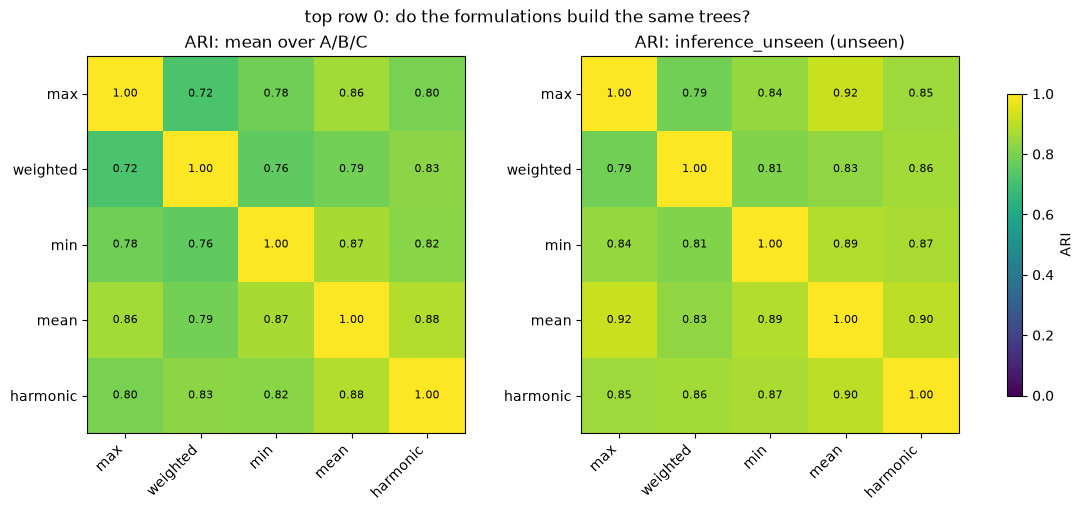

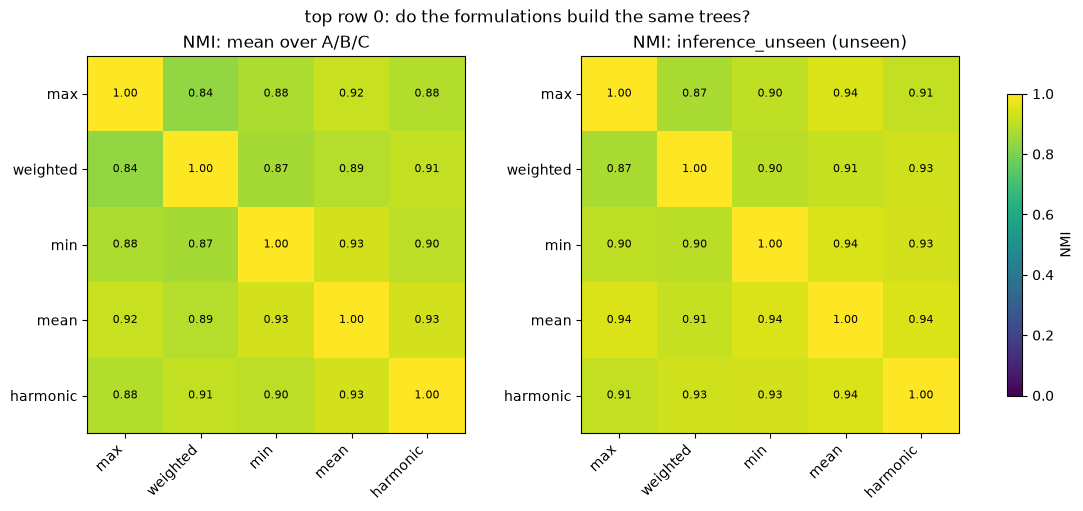

In [8]:
import itertools
import matplotlib.pyplot as plt
from polartox import normalized_mutual_information


def unseen_nmi(position):
    """Mean NMI of every pair of formulations on the unseen corpus (same texts as pairwise_ari)."""
    pipes = {variant: unseen_runs[position, variant][0] for variant in PEG_VARIANTS}
    shared = sorted(set.intersection(*(set(p.trees_) for p in pipes.values())))
    texts = {t: rows for t, rows in unseen.groupby("text_id", sort=False) if t in set(shared)}
    labels = {v: {t: pipes[v].trees_[t].leaf_labels(texts[t]) for t in shared} for v in pipes}
    matrix = pd.DataFrame(1.0, index=list(pipes), columns=list(pipes))
    for a, b in itertools.combinations(pipes, 2):
        matrix.loc[a, b] = matrix.loc[b, a] = np.mean(
            [normalized_mutual_information(labels[a][t], labels[b][t]) for t in shared])
    return matrix


def heatmap(ax, matrix, title):
    image = ax.imshow(matrix.values.astype(float), vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(matrix)), matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matrix)), matrix.index)
    for i, j in itertools.product(range(len(matrix)), repeat=2):
        value = matrix.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value < 0.6 else "black", fontsize=8)
    ax.set_title(title)
    return image


FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

for position in SELECTED:
    for measure, name in (("ari", "ARI"), ("nmi", "NMI")):
        abc = comparison.similarity(measure, position)
        unseen_matrix = unseen_ari[position][0] if measure == "ari" else unseen_nmi(position)
        fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
        heatmap(axes[0], abc, f"{name}: mean over A/B/C")
        image = heatmap(axes[1], unseen_matrix, f"{name}: {INFERENCE_CORPUS} (unseen)")
        fig.colorbar(image, ax=axes, shrink=0.8, label=name)
        fig.suptitle(f"top row {position}: do the formulations build the same trees?")
        fig.savefig(FIG_DIR / f"{measure}_heatmap_setting{position}.png", dpi=150)
        plt.show()


## 6. Which dimensions and subgroups? (F, C, P)

On the unseen corpus, for every formulation: **F** is the dimension used for the splits at each depth, **C** how consistently a subgroup lands on one pole (5 most frequent), **P** the mean PEG of the split that creates a subgroup (5 highest).

In [9]:
for (position, variant), (pipe, results) in unseen_runs.items():
    print(f"##### top row {position} | {variant}")
    display(results["F"])
    display(results["C"].head(5))
    display(results["P"].head(5))

##### top row 0 | max


depth,1,2,3
dim,,,
age,13,27,28
education,19,24,31
gender,11,23,39
orientation,26,26,22
politics,15,19,45


,n_s,frac_toxic,frac_civil
subgroup,,,
"((education, low),)",13,0.461538,0.538462
"((education, high),)",12,0.500000,0.500000
"((orientation, lgbtq+),)",11,0.545455,0.454545
"((orientation, heterosexual),)",11,0.545455,0.454545
"((education, medium),)",11,0.727273,0.272727


,n_s,mean_peg
subgroup,,
"((gender, male), (politics, center))",1,0.716268
"((gender, male), (politics, right))",1,0.716268
"((education, low), (politics, left))",1,0.696192
"((age, <25), (politics, right))",1,0.676224
"((orientation, lgbtq+),)",11,0.675417


##### top row 0 | weighted


...

,n_s,mean_peg
subgroup,,
"((education, low), (gender, non-binary), (politics, center))",1,0.714231
"((education, high), (gender, non-binary), (politics, left))",1,0.714105
"((education, high), (gender, non-binary), (politics, center))",1,0.714105
"((education, low), (orientation, heterosexual), (politics, center))",1,0.701121
"((age, 25-50), (gender, non-binary), (orientation, heterosexual))",1,0.695148


##### top row 0 | harmonic


depth,1,2,3
dim,,,
age,16,21,23
education,17,29,19
gender,15,21,20
orientation,25,25,27
politics,13,25,26


,n_s,frac_toxic,frac_civil
subgroup,,,
"((education, low),)",13,0.461538,0.538462
"((orientation, heterosexual),)",12,0.583333,0.416667
"((education, high),)",12,0.500000,0.500000
"((orientation, lgbtq+),)",12,0.500000,0.500000
"((education, medium),)",11,0.727273,0.272727


,n_s,mean_peg
subgroup,,
"((age, >50), (education, high), (politics, left))",1,0.721927
"((age, >50), (gender, male), (orientation, lgbtq+))",2,0.707905
"((education, low), (gender, non-binary), (politics, right))",1,0.686892
"((education, low), (gender, non-binary), (politics, center))",1,0.686892
"((education, low), (orientation, lgbtq+), (politics, center))",1,0.678253


## 7. The same text, different trees

Where do the formulations disagree most? For every text of A/B/C we take the mean ARI over all pairs of formulations; the lowest values are the texts on which the formulations build the most different trees (for the first chosen row). For each of them: the true structure, one line per formulation, and the trees themselves.

Set `TEXTS = [("A_default", 12), ...]` to look at specific texts instead.

In [10]:
N_TEXTS = 3
TEXTS = None        # or a list of (corpus, text_id)

disagreement = comparison.disagreement(SELECTED[0])     # lowest mean ARI first
display(disagreement.head(N_TEXTS))

chosen = TEXTS or list(zip(disagreement["corpus"].head(N_TEXTS), disagreement["text_id"].head(N_TEXTS)))

for corpus, text_id in chosen:
    comparison.show_text(corpus, text_id, SELECTED[0])

,corpus,text_id,k_true,mean_ari
0,B_weak_signal,27,2,0.260160
1,A_default,95,3,0.274462
2,B_weak_signal,65,3,0.296474


########## B_weak_signal, text 27 | true active dimensions: education (alpha 0.46), politics (alpha 0.49)
            first split                        dimensions used  leaves  depth  Jaccard
formulation                                                                           
max                 age               age, education, politics      15      3     0.67
weighted       politics  age, education, orientation, politics      10      3     0.50
min            politics       age, education, gender, politics      17      3     0.50
mean           politics  age, education, orientation, politics      16      3     0.50
harmonic           none                                   none       1      0     0.00
--- max ---
└── root (n=1620, nDFU=0.402) split 'age' (PEG=0.082)
    ├── age=25-50 (n=540, nDFU=0.304) split 'politics' (PEG=0.152)
    │   ├── politics=center (n=180, nDFU=0.457) split 'education' (PEG=0.326)
    │   │   ├── education=high (n=60, nDFU=0.783) -> [toxic] p_tox=0.600
 

## 8. Save

Everything goes into `benchmark_results/peg_comparison/`: `per_run.csv` has every number of every run and corpus, `overview.csv` the table of section 4, `recovery_by_k.csv` and `ari_by_k.csv` the by-k tables, `selected_settings.csv` the settings used, the ARI matrices and per-text values (A/B/C and the unseen corpus), and the complete F, C and P tables of the unseen corpus.

In [11]:
comparison.save(OUT_DIR)

for position, (matrix, per_text) in unseen_ari.items():
    matrix.to_csv(OUT_DIR / f"ari_setting{position}_{INFERENCE_CORPUS}.csv")
    per_text.to_csv(OUT_DIR / f"ari_per_text_setting{position}_{INFERENCE_CORPUS}.csv", index=False)

for (position, variant), (pipe, results) in unseen_runs.items():
    for name in "FCP":
        results[name].to_csv(OUT_DIR / f"{name}_top{position}_{variant}.csv")

print("Saved to:", OUT_DIR.resolve())

Saved to: C:\Users\swkra\OneDrive\Υπολογιστής\ερευνα\HumanModelAlign\polarizedtrees\benchmarks\benchmark_results\peg_comparison
